# Data Normalization for Multi-Omics

**Learning Objectives**

By the end of this 30-minute exercise you will be able to:

1. Explain *why* normalization is necessary before comparing samples in omics experiments.
2. Compute **RPKM** and **TPM** for RNA-seq read counts and describe when each is appropriate.
3. Apply **quantile normalization** to intensity-based data (microarray / proteomics).
4. Apply **Pareto scaling** to metabolomics data and contrast it with autoscaling.

**Data file:** `gene_treatment_data.txt` (5 genes, 6 samples, with gene lengths)

**Structure:** Each section has a worked example followed by a short exercise.  
Exercises are "fill in the blank" — look for lines marked `### YOUR CODE HERE ###`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, powerlaw

# Consistent plot style for the session
plt.rcParams.update({"figure.figsize": (8, 3.5), "axes.titlesize": 13})

---
## Section 1: RNA-seq Normalization — RPKM and TPM (~10 min)

### Why normalize RNA-seq counts?

Raw read counts for a gene depend on two **technical factors** that have nothing to do with biology:

| Bias | Cause | Fix |
|------|-------|-----|
| **Sequencing depth** | A sample sequenced more deeply produces more reads for *every* gene. | Divide by total reads (per-million scaling). |
| **Gene length** | Longer transcripts capture more reads even at equal expression. | Divide by gene length (per-kilobase scaling). |

**RPKM** (Reads Per Kilobase per Million mapped reads) corrects for both:

$$\text{RPKM} = \frac{\text{read count}}{\left(\frac{\text{gene length}}{10^3}\right) \times \left(\frac{\text{total reads}}{10^6}\right)}$$

**TPM** (Transcripts Per Million) also corrects for both biases, but normalizes *per sample* so that the column totals are always 1,000,000, making samples directly comparable:

$$\text{TPM}_i = \frac{\text{read count}_i \;/\; \text{gene length}_i}{\sum_j \left(\text{read count}_j \;/\; \text{gene length}_j\right)} \times 10^6$$

> **Rule of thumb:** TPM is preferred in modern analyses because RPKM column sums differ between samples, which can distort cross-sample comparisons.

In [2]:
# Load the gene expression data (5 genes, 6 samples + gene length column)
gene_data = pd.read_csv("gene_treatment_data.txt", sep="\t", index_col=0)
print(f"Shape: {gene_data.shape}")
gene_data

Shape: (5, 7)


,ctr1,ctr2,ctr3,trt1,trt2,trt3,length
gene,,,,,,,
gene1,338,324,246,291,202,168,1982.0
gene2,49,21,53,16,16,11,4769.0
gene3,39,49,30,46,52,25,1096.0
gene4,530,530,499,499,386,264,3868.0
gene5,12,3,4,3,10,7,702.0


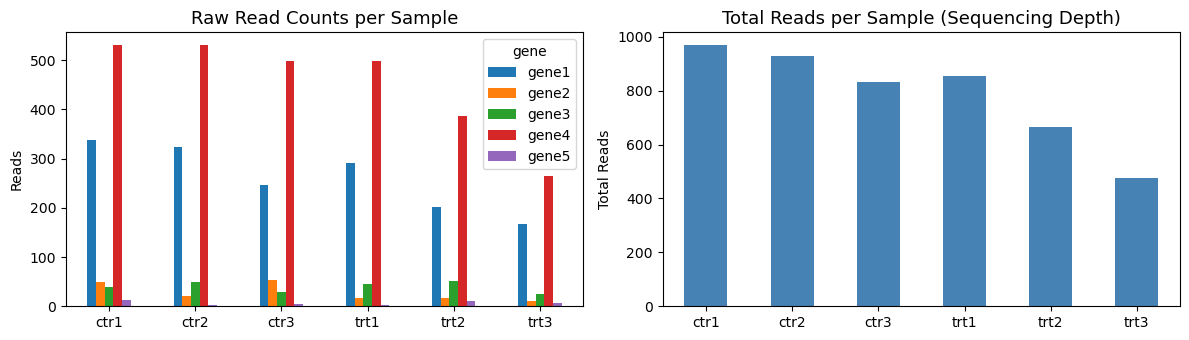

In [3]:
# Separate the count columns from the gene length column
counts = gene_data.iloc[:, 0:6]   # 5 genes x 6 samples
lengths = gene_data["length"]      # gene lengths in base pairs

# Visualize the raw data — notice how samples have different totals (sequencing depth)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

counts.T.plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Raw Read Counts per Sample")
axes[0].set_ylabel("Reads")

counts.sum().plot.bar(ax=axes[1], color="steelblue", rot=0)
axes[1].set_title("Total Reads per Sample (Sequencing Depth)")
axes[1].set_ylabel("Total Reads")

plt.tight_layout()
plt.show()

In [4]:
# --- RPKM calculation (vectorized) ---
# total_reads: sum of counts per sample (column sums)
total_reads = counts.sum()

# Divide each count by (gene_length_in_kb * total_reads_in_millions)
rpkm = counts / (lengths.values[:, None] / 1e3) / (total_reads.values / 1e6)

print("RPKM values:")
rpkm.round(1)

RPKM values:


,ctr1,ctr2,ctr3,trt1,trt2,trt3
gene,,,,,,
gene1,176172.3,176344.4,149179.2,171720.9,153028.9,178448.1
gene2,10614.3,4750.2,13357.5,3924.0,5037.5,4855.9
gene3,36760.3,48228.7,32899.4,49088.7,71239.1,48021.5
gene4,141551.4,147812.0,155056.8,150885.7,149839.6,143689.1
gene5,17659.1,4610.0,6848.6,4998.3,21388.9,20992.7


In [5]:
# --- TPM calculation ---
# Step 1: compute the rate = reads per kilobase of gene
rate = counts.div(lengths / 1e3, axis=0)

# Step 2: scale each sample (column) so that the sum equals 1,000,000
tpm = rate / rate.sum() * 1e6

print("TPM column sums (should each be 1,000,000):")
print(tpm.sum().round(1))
print()
tpm.round(1)

TPM column sums (should each be 1,000,000):
ctr1    1000000.0
ctr2    1000000.0
ctr3    1000000.0
trt1    1000000.0
trt2    1000000.0
trt3    1000000.0
dtype: float64



,ctr1,ctr2,ctr3,trt1,trt2,trt3
gene,,,,,,
gene1,460271.5,461942.5,417469.6,451164.1,382062.1,450618.3
gene2,27731.3,12443.4,37380.2,10309.5,12577.1,12262.2
gene3,96040.6,126337.4,92067.0,128971.1,177860.3,121264.2
gene4,369820.0,387200.5,433917.8,396423.4,374099.5,362844.6
gene5,46136.6,12076.2,19165.3,13132.0,53401.0,53010.8


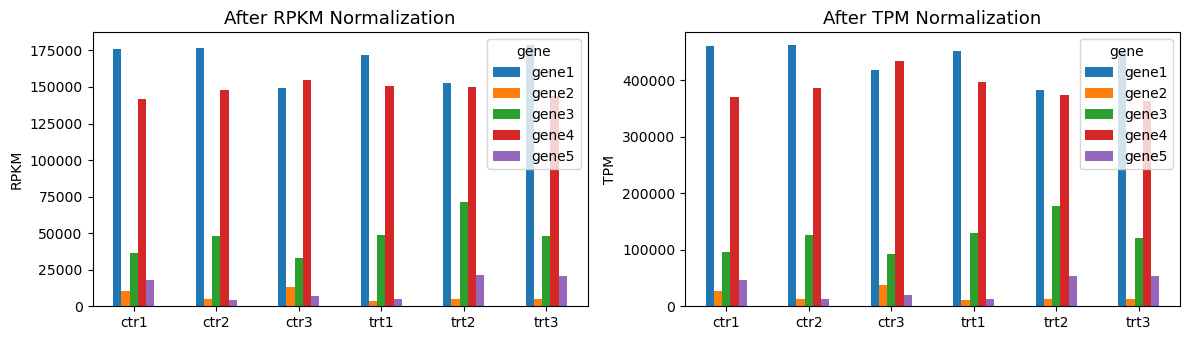

RPKM column sums: [382757.4, 381745.3, 357341.3, 380617.5, 400534.1, 396007.3]
TPM  column sums: [1000000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0]


In [6]:
# Compare RPKM vs TPM side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

rpkm.T.plot.bar(ax=axes[0], rot=0)
axes[0].set_title("After RPKM Normalization")
axes[0].set_ylabel("RPKM")

tpm.T.plot.bar(ax=axes[1], rot=0)
axes[1].set_title("After TPM Normalization")
axes[1].set_ylabel("TPM")

plt.tight_layout()
plt.show()

# Notice: RPKM column sums differ, TPM column sums are all 1,000,000
print("RPKM column sums:", rpkm.sum().round(1).tolist())
print("TPM  column sums:", tpm.sum().round(1).tolist())

### Exercise 1 — Compute RPKM and TPM yourself

The cell below creates a small synthetic dataset with 3 genes and 2 samples.  
Fill in the missing lines to compute RPKM and TPM.

In [7]:
# Synthetic data
ex_counts = pd.DataFrame(
    {"sample_A": [200, 100, 50], "sample_B": [300, 80, 70]},
    index=["geneX", "geneY", "geneZ"],
)
ex_lengths = pd.Series([2000, 500, 1000], index=ex_counts.index, name="length")

print("Counts:")
print(ex_counts, "\n")
print("Gene lengths:")
print(ex_lengths, "\n")

# --- RPKM ---
ex_total = ex_counts.sum()
ex_rpkm = ### YOUR CODE HERE ###   # one-line vectorized RPKM formula

print("RPKM:")
print(ex_rpkm.round(1), "\n")
#Mip, in super process.
# --- TPM ---
ex_rate = ### YOUR CODE HERE ###    # reads divided by gene length in kb
ex_tpm  = ### YOUR CODE HERE ###    # scale so each column sums to 1e6

print("TPM:")
print(ex_tpm.round(1))
print("TPM column sums:", ex_tpm.sum().round(1).tolist())

SyntaxError: invalid syntax (603950166.py, line 15)

---
## Section 2: Quantile Normalization — Microarray / Proteomics (~8 min)

### When and why

Microarray and label-free proteomics produce **intensity** values. Technical variation (dye bias, detector differences) causes the intensity *distributions* to differ across samples even when the underlying biology is the same.

**Quantile normalization** forces every sample to have the *same* distribution by:

1. **Sort** each column independently.
2. **Average** across each row of the sorted matrix.
3. **Replace** each original value with the average that matches its rank.

> This is a strong assumption — it works well when most features are *not* differentially expressed or abundant.

In [47]:
# --- Small worked example (4 genes, 3 samples) ---
df_toy = pd.DataFrame(
    {"C1": {"A": 5, "B": 2, "C": 3, "D": 4},
     "C2": {"A": 4, "B": 1, "C": 4, "D": 2},
     "C3": {"A": 3, "B": 4, "C": 6, "D": 8}},
)
print("Original data:")
display(df_toy)

Original data:


,C1,C2,C3
A,5,4,3
B,2,1,4
C,3,4,6
D,4,2,8


In [48]:
# Step 1: Sort each column independently
df_sorted = pd.DataFrame(
    np.sort(df_toy.values, axis=0), index=df_toy.index, columns=df_toy.columns
)
print("Step 1 — Sorted columns:")
display(df_sorted)

# Step 2: Compute the row means of the sorted data
row_means = df_sorted.mean(axis=1)
row_means.index = np.arange(1, len(row_means) + 1)  # label by rank
print("Step 2 — Row means (one value per rank):")
print(row_means, "\n")

# Step 3: Map each original value's rank to the corresponding row mean
df_qn = df_toy.rank(method="min").stack().astype(int).map(row_means).unstack()
print("Step 3 — Quantile-normalized data:")
display(df_qn)

Step 1 — Sorted columns:


,C1,C2,C3
A,2,1,3
B,3,2,4
C,4,4,6
D,5,4,8


Step 2 — Row means (one value per rank):
1    2.000000
2    3.000000
3    4.666667
4    5.666667
dtype: float64 

Step 3 — Quantile-normalized data:


,C1,C2,C3
A,5.666667,4.666667,2.000000
B,2.000000,2.000000,3.000000
C,3.000000,4.666667,4.666667
D,4.666667,3.000000,5.666667


In [49]:
# Wrap it into a reusable function
def quantile_normalize(df):
    """Quantile-normalize columns of a numeric DataFrame."""
    df_sorted = pd.DataFrame(
        np.sort(df.values, axis=0), index=df.index, columns=df.columns
    )
    row_means = df_sorted.mean(axis=1)
    row_means.index = np.arange(1, len(row_means) + 1)
    return df.rank(method="min").stack().astype(int).map(row_means).unstack()

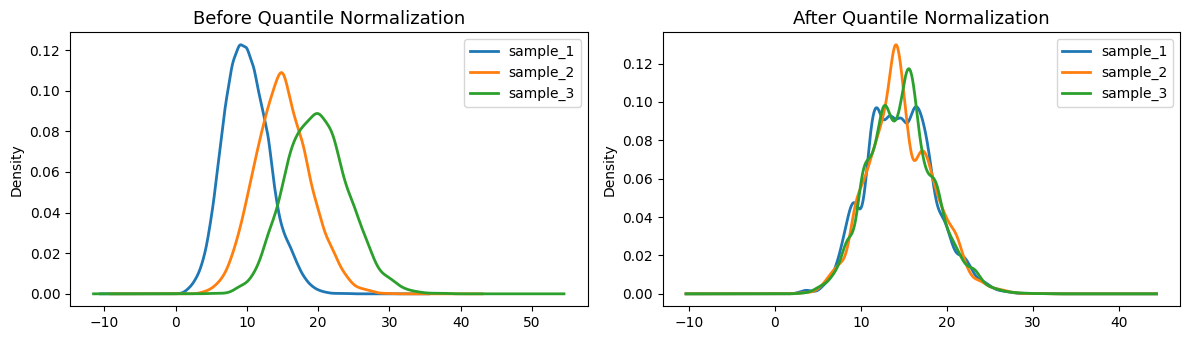

In [50]:
# Test on simulated proteomics data: 3 samples with different Poisson means
np.random.seed(42)
df_prot = pd.DataFrame({
    "sample_1": poisson.rvs(mu=10, size=5000),
    "sample_2": poisson.rvs(mu=15, size=5000),
    "sample_3": poisson.rvs(mu=20, size=5000),
})

df_prot_qn = quantile_normalize(df_prot)

# Before / after density plots
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
df_prot.plot.density(ax=axes[0], linewidth=2)
axes[0].set_title("Before Quantile Normalization")
df_prot_qn.plot.density(ax=axes[1], linewidth=2)
axes[1].set_title("After Quantile Normalization")
plt.tight_layout()
plt.show()

### Exercise 2 — Quantile-normalize a new dataset

Generate 4 samples of 2000 features each, drawn from Poisson distributions with means 5, 12, 25, and 40. Apply quantile normalization, then make a before/after density plot.

In [ ]:
np.random.seed(7)

df_ex2 = pd.DataFrame({
    "S1": poisson.rvs(mu=5,  size=2000),
    "S2": poisson.rvs(mu=12, size=2000),
    "S3": ### YOUR CODE HERE ###,
    "S4": ### YOUR CODE HERE ###,
})

df_ex2_qn = ### YOUR CODE HERE ###   # apply quantile normalization

# Plot before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
### YOUR CODE HERE ###   # density plot on axes[0] (before) and axes[1] (after)
plt.tight_layout()
plt.show()

---
## Section 3: Scaling for Metabolomics — Pareto and Autoscaling (~8 min)

### The problem

LC-MS metabolomics data spans several orders of magnitude. A few high-abundance metabolites dominate the variance, masking biologically interesting low-abundance signals.

**Scaling** (applied *per feature*, across samples) addresses this:

| Method | Formula (for feature *i*) | Effect |
|--------|--------------------------|--------|
| **Autoscaling** (z-score) | $(x - \bar{x}) / s$ | Every feature gets unit variance. Can inflate noisy features. |
| **Pareto scaling** | $(x - \bar{x}) / \sqrt{s}$ | Down-weights large features less aggressively than autoscaling. Preferred for metabolomics. |

> **Note:** Scaling operates across *samples for each feature* (row-wise when features are rows), unlike quantile normalization which operates on whole columns.

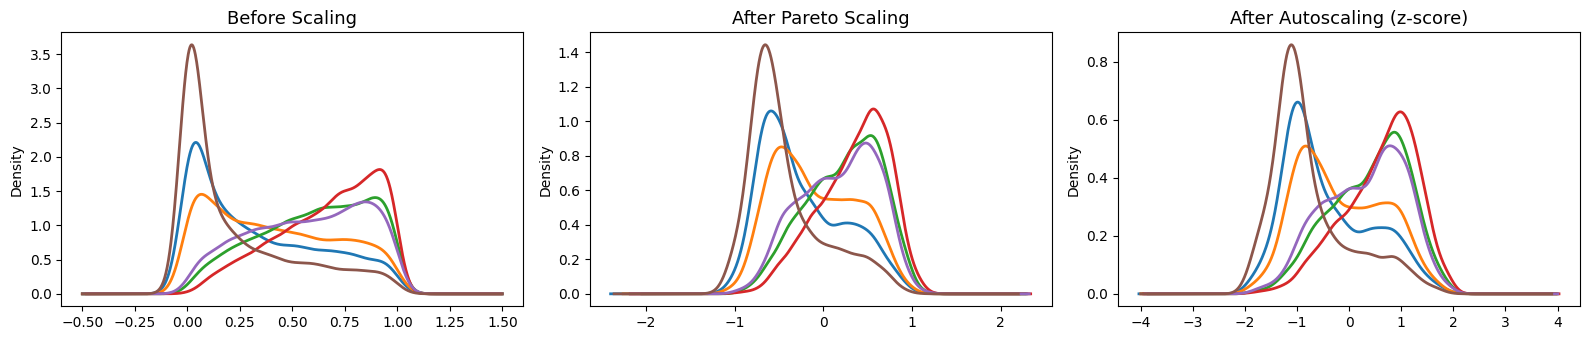

In [52]:
# Simulate 6 metabolomics samples with different power-law shapes
np.random.seed(21)
df_met = pd.DataFrame({
    f"sample_{i+1}": powerlaw.rvs(a, size=5000)
    for i, a in enumerate([0.5, 0.7, 1.5, 2.0, 1.3, 0.3])
})

# Feature-wise statistics (each row = one metabolite measured across 6 samples)
row_mean = df_met.mean(axis=1)
row_std  = df_met.std(axis=1)

# Pareto scaling: subtract mean, divide by sqrt(std)
df_pareto = df_met.sub(row_mean, axis=0).div(np.sqrt(row_std), axis=0)

# Autoscaling (z-score): subtract mean, divide by std
df_auto = df_met.sub(row_mean, axis=0).div(row_std, axis=0)

# Compare all three
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
df_met.plot.density(ax=axes[0], linewidth=2, legend=False)
axes[0].set_title("Before Scaling")
df_pareto.plot.density(ax=axes[1], linewidth=2, legend=False)
axes[1].set_title("After Pareto Scaling")
df_auto.plot.density(ax=axes[2], linewidth=2, legend=False)
axes[2].set_title("After Autoscaling (z-score)")
plt.tight_layout()
plt.show()

### Exercise 3 — Implement Pareto scaling

Using the `df_met` DataFrame from above, implement Pareto scaling yourself. Then answer the question at the bottom.

In [ ]:
# Compute the row (feature) mean and standard deviation
feat_mean = ### YOUR CODE HERE ###
feat_std  = ### YOUR CODE HERE ###

# Pareto scaling: subtract mean, divide by sqrt of std
df_pareto_ex = ### YOUR CODE HERE ###

# Quick check — plot one sample before and after
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
df_met["sample_1"].plot.density(ax=axes[0], linewidth=2, color="coral")
axes[0].set_title("sample_1 — Raw")
df_pareto_ex["sample_1"].plot.density(ax=axes[1], linewidth=2, color="teal")
axes[1].set_title("sample_1 — Pareto Scaled")
plt.tight_layout()
plt.show()

# QUESTION: Why might you prefer Pareto scaling over autoscaling
# for metabolomics data?
#
### YOUR ANSWER HERE ###

---
## Section 4: Summary and Reflection (~4 min)

| Omics type | Typical normalization | Key idea |
|------------|----------------------|----------|
| RNA-seq | RPKM / TPM | Correct for **gene length** and **sequencing depth** |
| Microarray / Proteomics | Quantile normalization | Force all samples to share the **same distribution** |
| Metabolomics | Pareto / Autoscaling | Reduce dominance of **high-variance features** |

### Key take-aways

- **Always visualize** your data before and after normalization.
- No single method works for all data types — the right choice depends on the technology and its specific biases.
- TPM is generally preferred over RPKM for RNA-seq because column totals are consistent across samples.

### Exercise 4 — Match the method

Replace each `"???"` with the correct normalization method name from:  
`"RPKM"`, `"TPM"`, `"Quantile"`, `"Pareto"`, `"Autoscaling"`

In [ ]:
answers = {
    "Corrects for gene length and sequencing depth; column sums vary":          "???",
    "Corrects for gene length and sequencing depth; column sums are 1e6":       "???",
    "Forces identical distributions across samples":                            "???",
    "Mean-centers and divides by sqrt(sd); good for metabolomics":              "???",
    "Mean-centers and divides by sd; can inflate noisy low-abundance features": "???",
}

for description, answer in answers.items():
    print(f"  {answer:>12s}  <-  {description}")

---
### Further Reading

- Zhao et al. (2020) — [TPM, FPKM, or Normalized Counts? A Comparative Study](https://doi.org/10.1186/s12859-020-03622-0)
- Hicks & Irizarry (2015) — [Quantile normalization assumptions and consequences](https://www.biorxiv.org/content/10.1101/012203v1.full)
- van den Berg et al. (2006) — [Centering, scaling, and transformations for metabolomics](https://doi.org/10.1186/1471-2164-7-142)

In [ ]:
print("DONE")